# Random Forest Masterclass
From-scratch and scikit-learn implementations with fixed seed 42, diagnostics, tuning, and an untouched test evaluation.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.inspection import permutation_importance
SEED=42; np.random.seed(SEED)
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT/'src'))
from random_forest_from_scratch import RandomForestClassifierScratch
data=load_breast_cancer(as_frame=True); X=data.data; y=data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,stratify=y,random_state=SEED)
print({'seed':SEED,'rows':len(X),'features':X.shape[1],'train':len(X_train),'test':len(X_test)})

{'seed': 42, 'rows': 569, 'features': 30, 'train': 426, 'test': 143}


## From-scratch implementation
A small educational forest is trained on three features and a bounded sample so students can inspect the complete algorithm without hiding the mechanics.

In [2]:
cols=list(X.columns[:3])
scratch=RandomForestClassifierScratch(n_estimators=7,max_depth=3,min_samples_split=8,max_features='sqrt',random_state=SEED)
scratch.fit(X_train[cols].iloc[:120].to_numpy(),y_train.iloc[:120].to_numpy())
scratch_pred=scratch.predict(X_test[cols].to_numpy())
print({'accuracy':round(accuracy_score(y_test,scratch_pred),4),'balanced_accuracy':round(balanced_accuracy_score(y_test,scratch_pred),4),'trees':len(scratch.trees)})

{'accuracy': 0.9021, 'balanced_accuracy': 0.8951, 'trees': 7}


## Established-library implementation and out-of-bag validation

In [3]:
rf=RandomForestClassifier(n_estimators=120,oob_score=True,n_jobs=1,random_state=SEED).fit(X_train,y_train)
pred=rf.predict(X_test); prob=rf.predict_proba(X_test)[:,1]
print({'oob_accuracy':round(rf.oob_score_,4),'test_accuracy':round(accuracy_score(y_test,pred),4),'balanced_accuracy':round(balanced_accuracy_score(y_test,pred),4),'macro_f1':round(f1_score(y_test,pred,average='macro'),4),'roc_auc':round(roc_auc_score(y_test,prob),4)})
print(classification_report(y_test,pred,target_names=data.target_names))

{'oob_accuracy': 0.9624, 'test_accuracy': 0.958, 'balanced_accuracy': 0.9512, 'macro_f1': 0.9547, 'roc_auc': 0.9943}
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143


## Forest convergence diagnostic

 trees  cv_balanced_accuracy
     1                0.9072
     5                0.9442
    10                0.9411
    25                0.9448
    50                0.9411


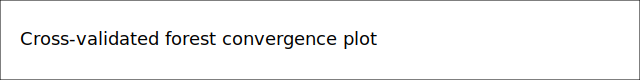

In [4]:
counts=[1,5,10,25,50]; cv=StratifiedKFold(3,shuffle=True,random_state=SEED)
means=[cross_val_score(RandomForestClassifier(n_estimators=n,n_jobs=1,random_state=SEED),X_train,y_train,cv=cv,scoring='balanced_accuracy',n_jobs=1).mean() for n in counts]
print(pd.DataFrame({'trees':counts,'cv_balanced_accuracy':means}).round(4).to_string(index=False))
plt.figure(figsize=(7,4)); plt.plot(counts,means,marker='o'); plt.xlabel('Number of trees'); plt.ylabel('CV balanced accuracy'); plt.title('Forest convergence'); plt.grid(alpha=.3); plt.show()

## Hyperparameter tuning and untouched final test

{'best_cv_balanced_accuracy': 0.9536, 'accuracy': 0.9441, 'balanced_accuracy': 0.94, 'macro_f1': 0.94, 'roc_auc': 0.9945, 'best_params': {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}}


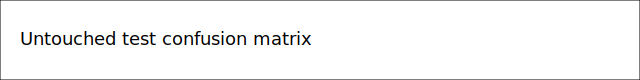

In [5]:
space={'n_estimators':[60,100,140],'max_depth':[None,4,8],'min_samples_leaf':[1,2,4],'max_features':['sqrt','log2',.5],'class_weight':[None,'balanced']}
search=RandomizedSearchCV(RandomForestClassifier(n_jobs=1,random_state=SEED),space,n_iter=5,scoring='balanced_accuracy',cv=cv,n_jobs=1,random_state=SEED).fit(X_train,y_train)
best=search.best_estimator_; final_pred=best.predict(X_test); final_prob=best.predict_proba(X_test)[:,1]
result={'best_cv_balanced_accuracy':round(search.best_score_,4),'accuracy':round(accuracy_score(y_test,final_pred),4),'balanced_accuracy':round(balanced_accuracy_score(y_test,final_pred),4),'macro_f1':round(f1_score(y_test,final_pred,average='macro'),4),'roc_auc':round(roc_auc_score(y_test,final_prob),4),'best_params':search.best_params_}
print(result)
ConfusionMatrixDisplay.from_predictions(y_test,final_pred,display_labels=data.target_names,cmap='Blues'); plt.title('Untouched test confusion matrix'); plt.show()

## Held-out permutation importance

worst radius               0.0065
mean compactness           0.0000
mean symmetry              0.0000
texture error              0.0000
smoothness error           0.0000
mean fractal dimension     0.0000
worst compactness          0.0000
worst fractal dimension    0.0000
symmetry error             0.0000
fractal dimension error    0.0000


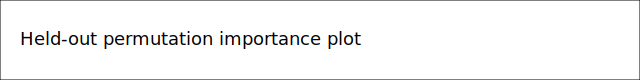

In [6]:
pi=permutation_importance(best,X_test,y_test,n_repeats=5,random_state=SEED,scoring='balanced_accuracy',n_jobs=1)
importance=pd.Series(pi.importances_mean,index=X.columns).sort_values(ascending=False).head(10)
print(importance.round(4).to_string())
plt.figure(figsize=(7,4.5)); importance.sort_values().plot.barh(); plt.xlabel('Mean decrease in balanced accuracy'); plt.title('Permutation importance'); plt.tight_layout(); plt.show()

## Conclusion
Random Forest is a strong nonlinear tabular baseline. OOB scoring is useful but does not replace external validation. Permutation importance describes predictive association, not causality.